# **MÓDULO 19** - Exercício: Estatística Aplicada

# Análise Estatística: Comparação entre Estratégias de Ensino

## Objetivo

Avaliar se a Estratégia B apresenta desempenho médio superior à Estratégia A por meio de um teste de hipótese (Teste Z).

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [14]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1 Definição do tipo de teste estatístico

O teste é unilateral à direita, pois a hipótese alternativa afirma que a média das notas da Estratégia B é maior do que a média das notas da Estratégia A. Ou seja, queremos testar se a média da Estratégia de B é maior que a média da Estratégia de A. Como o interesse está apenas em verificar se a Estratégia B apresenta desempenho superior, e não apenas diferente, o teste é unilateral à direita.

# 2 Análise descritiva das amostras

In [10]:
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

variancia_A = np.var(amostra_estrategia_A, ddof=1)
variancia_B = np.var(amostra_estrategia_B, ddof=1)

print(f"Média da Estratégia A: {media_A:.2f}")
print(f"Média da Estratégia B: {media_B:.2f}")
print(f"Variância da Estratégia A: {variancia_A:.2f}")
print(f"Variância da Estratégia B: {variancia_B:.2f}")

Média da Estratégia A: 71.41
Média da Estratégia B: 74.75
Variância da Estratégia A: 129.27
Variância da Estratégia B: 110.47


Observa-se que:

* A média da Estratégia B é maior que a da Estratégia A, indicando um desempenho médio superior.
* No entanto, a variância da Estratégia A é maior que a da Estratégia B neste caso, indicando que as notas da Estratégia A estão mais dispersas.
* Isso sugere que, embora a Estratégia B apresente melhor desempenho médio, a diferença entre as estratégias pode não ser suficientemente consistente, o que reforça a necessidade do teste estatístico para verificar se essa diferença é significativa.

# 3 Teste de hipótese (Teste Z)

In [11]:
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

z = (media_B - media_A) / np.sqrt((variancia_A / n_A) + (variancia_B / n_B))

p_value = 1 - stats.norm.cdf(z)

print(f"Estatística Z: {z:.4f}")
print(f"p-value: {p_value:.4f}")

nivel_significancia = 0.05

if p_value < nivel_significancia:
    print("Rejeitamos a hipótese nula.")
else:
    print("Não rejeitamos a hipótese nula.")

Estatística Z: 1.5267
p-value: 0.0634
Não rejeitamos a hipótese nula.


Considerando o nível de significância de 5% ( = 0,05), comparamos o p-value obtido no teste com esse valor:

* O p-value calculado foi aproximadamente 0,0634, que é maior que 0,05. Portanto, não rejeitamos a hipótese nula.
* Isso indica que não há evidências estatísticas suficientes para afirmar que a média das notas da Estratégia B é maior do que a da Estratégia A.
* Apesar da média da Estratégia B ser numericamente maior, essa diferença pode ser explicada pela variabilidade dos dados, não sendo estatisticamente significativa ao nível de 5%.

# 4 Visualização da distribuição e interpretação

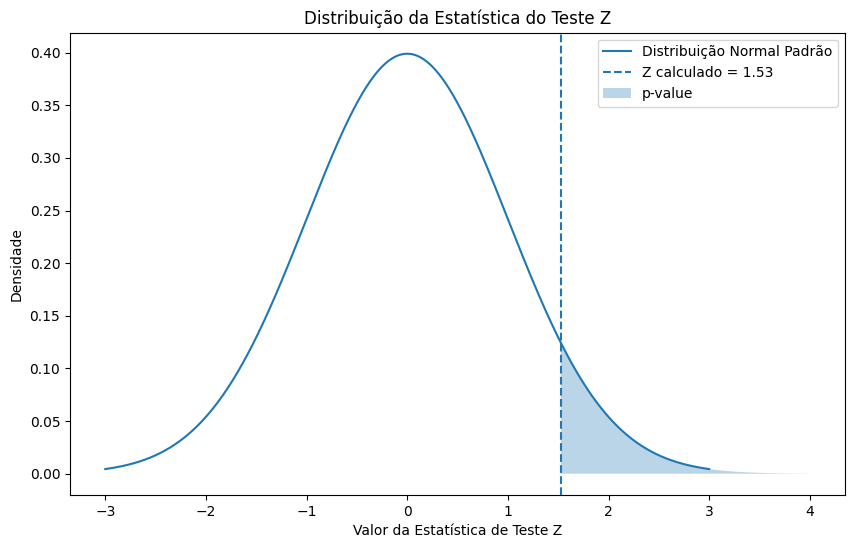

In [19]:
x = np.linspace(-3, 3, 1000)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="Distribuição Normal Padrão")

plt.axvline(z, linestyle="--", label=f"Z calculado = {z:.2f}")

x_area = np.linspace(z, 4, 1000)
y_area = stats.norm.pdf(x_area)
plt.fill_between(x_area, y_area, alpha=0.3, label="p-value")

plt.title("Distribuição da Estatística do Teste Z")
plt.xlabel("Valor da Estatística de Teste Z")
plt.ylabel("Densidade")
plt.legend()
plt.show()

O gráfico apresenta a distribuição normal padrão utilizada no teste Z. Desta forma, podemos observar que:

* A linha tracejada representa o valor da estatística Z calculada, enquanto a área sombreada à direita representa o p-value.
* Como o teste é unilateral à direita, analisamos apenas a cauda direita da distribuição.
* Observa-se que o valor de Z não está suficientemente distante da média da distribuição (0), resultando em uma área relativamente grande à direita (p-value). Isso indica que a probabilidade de observarmos essa diferença entre as médias apenas por acaso não é pequena o suficiente para rejeitar a hipótese nula.

# 5 Conclusão


Os resultados indicam que, apesar da Estratégia B apresentar média superior, não há evidências estatísticas suficientes, ao nível de significância de 5%, para afirmar que ela é melhor que a Estratégia A.